# <span style="color:blue">Workshop 6: Competitive Coevolution</span>

## <span style="color:#0073e6">Learning objectives</span>

- To implement a simple competitive coevolutionary algorithm using DEAP
- To understand how the populations interact and the impact of changing parameters in each population
- Implement a common version of fitness sharing (diversity measure)

# <span style="color:blue">Practical Instructions</span>

This task takes a toy game to explore competitive evolution in a simplistic domain. The game is called the Matching Game and is a coevolutionary version of the max-ones game.

In this simple immune system-inspired game, there are two populations: parasites and hosts. Each population is represented by a bit-string. Parasites are rewarded for the number of their binary genes that match the corresponding binary genes of hosts, but hosts are rewarded for the number of genes
 that mismatch with the parasites. Games of this type often result in coevolutionary cycling, because hosts chase parasites through solution space.

**Fitness function:** Not all genes are always involved in this matching game. For parasites with many 1-alleles, the matching game tends to involve only those genes at which the parasite possesses 1-alleles. For parasites with many 0-alleles, the game tends to involve only those genes at which the parasite possesses 0-alleles. Whether 1-allele genes or 0-allele genes are involved is determined probabilistically. The probability, p, of a game involving matching 1-alleles increases with the total number of 1-alleles, x, that the parasite has such that:

$p = \frac{1}{2} \{ 1+\tanh(\frac{x-50}{7}) \}$

Otherwise the game matches based on only 0-alleles for that parasite and its host opponents.

Once the game has been decided, the fitness of the host is the number of genes that it mismatches for each individual, and the fitness of the parasite is the number of genes that match for each individual.

**If you want to start with a simpler version of the problem, you can implement the game with a simple evaluation function based simply on the number of genes matched (for the parasite) or unmatched (for the host), and then move on to this more complicated version.**

If you want to read more about a coevolutionary algorithm implementing this game, then you can read the paper:

> J. Cartlidge and S. Bullock, "Combating Coevolutionary Disengagement by Reducing Parasite Virulence," in Evolutionary Computation, vol. 12, no. 2, pp. 193-222, June 2004, doi: 10.1162/106365604773955148.

A copy is available on the VLE as matchingGame.pdf.

# <span style="color:blue">Exercise 1: Implement the coevolutionary problem</span>

Your task is to implement this game in DEAP. DEAP does not implement parasitic coevolution directly. However, parasitic evolution is simply two evolutionary algorithms running simultaneously, with the fitness of each population linked. So you can implement this using your current knowledge of DEAP. Implement the problem and try to understand the results.

**Implementation Details**

I suggest using the max-ones code you developed in the first practical as a starting point.
- Use two distinct populations (species) of size 50 each (hosts / parasites)
- Individuals in each population consist of binary strings containing 100 bits, initialised at random at generation 0.
- In each generation, members of the host population are selected to play a set of pair-wise contests against a random sample of 5 opponents from the parasite population.
- Each individual has a small probability of a bit-flip mutation with a probability per gene of 0.05 (indpb=0.05) for each population
- Use tournament selection with size 6
- Run for 150 generations to start with
- **Unlike standard evolution, you should not check to see if an individual has been modified (e.g. remove ‘invalid_ind’ and ‘del mutant.fitness.values’) before assessing their fitness, because relative fitness can change even if they have not been modified. Thus, you always need to reassess fitness.**

**Things to do:**
- To explore the coevolution of the hosts and parasites, plot the average number of 1s in each generation, for each population alongside each other on a graph.
- Try giving a high mutation rate (e.g. indpb=0.1) to the parasite, and lower to the host (e.g. indpb=0.01). How does this change the coevolutionary dynamic?
- Now reverse those mutation rates, so that the host has a mutational advantage. How does this change the coevolutionary dynamic?

## <span style="color:#0073e6">Live plotting</span>

Let's plot progress as the code runs. First, define your axes and that you will be plotting live. Do this when you are initializing your algorithm:

In [1]:
#plt.axis([0, NGEN, 0, 100])
#plt.ion()

At the end of the generation, within the loop, you can now plot the number of ones for each individual in each population using the code:

In [2]:
#for index in range(POPSIZE):
#    plt.scatter( g, sum(popHost[index]), color='red', s=15, alpha=0.1)
#    plt.scatter( g, sum(popParasite[index]), color='blue', s=15, alpha=0.1)
#    plt.pause(0.00001)

# <span style="color:Blue">Code for the competitive coevolution example</span>

In [4]:
!pip install deap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 2.0 MB/s eta 0:00:00


In [5]:
import random
from deap import base
from deap import creator
from deap import tools
import numpy as np
import sys
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
from IPython import display

In [7]:
#Both parasite and host populations are trying to maximise their fitness
#So we can use creator.FitnexxMax for both ParasiteIndividual and HostIndividual
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("ParasiteIndividual", list, fitness=creator.FitnessMax)
creator.create("HostIndividual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

#Genes are going to be random {0, 1] integers
toolbox.register("attr_bool", random.randint, 0, 1)

#Register the Individual types - both are a list of 100 Boolean values
NUM_GENES = 100
toolbox.register("ParasiteIndividual", tools.initRepeat, creator.ParasiteIndividual, toolbox.attr_bool, NUM_GENES)
toolbox.register("HostIndividual", tools.initRepeat, creator.HostIndividual, toolbox.attr_bool, NUM_GENES)

#Register the two Population types - both are a list of their respective individuals
toolbox.register("HostPopulation", tools.initRepeat, list, toolbox.HostIndividual)
toolbox.register("ParasitePopulation", tools.initRepeat, list, toolbox.ParasiteIndividual)

In [8]:
def evalHost(individual):
    #To evaluate the fitness of a Host individual, we pair it with N random parasites
    #In this case N = 5
    fit = 0.0
    numOpponents = 5

    #Select N random opponents from the parasite population
    opponentIndexes = np.random.choice(len(popParasite), size=numOpponents, replace=False)
    opponents = [popParasite[i] for i in opponentIndexes]

    #For each opponent we are going to calculate a fitness of the host
    # by counting either NON-matching 1s or NON-matching 0s
    for opp in opponents:
        #Count the number of 1s in the parassite by summing the individual's genes
        x = sum(opp)

        #For this opponent, calculate the probability we will match against 1s
        #NOTE: This is inside the loop because we look at the Parasite 1s, which are different every time
        p = 0.5 * ( 1 + np.tanh( (x - 50) / 7 ) )
        if random.random() < p:
            matchingOnes = True
        else:
            matchingOnes = False

        #Step through the genes and either match 1s or match 0s
        for i in range(len(individual)):
            #If we are matching 1s, and the host has a 0, add to fitness
            if matchingOnes and opp[i] == 1 and individual[i] == 0:
                fit += 1
            #If we are matching 0s, and the host has a 1, add to fitness
            elif not(matchingOnes) and opp[i] == 0 and individual[i] == 1:
                fit += 1

    #We have added fitnesses over N opponents, so divide by N to scale the fitness
    return (fit/numOpponents),

In [9]:
def evalParasite(individual):
    #To evaluate the fitness of a Parasite individual, we pair it with N random Hosts
    #In this case N = 5
    fit = 0.0
    numOpponents = 5

    #Calculate the probability we will match against 1s
    #NOTE: This is outside the loop because we look at the Parasite 1s, which are the same every time
    x = sum(individual)
    p = 0.5 * ( 1 + np.tanh( (x - 50) / 7 ) )
    if random.random() < p:
        matchingOnes = True
    else:
        matchingOnes = False

    # Select numOpponents random individuals from the host population
    opponentIndexes = np.random.choice(len(popHost), size=numOpponents, replace=False)
    opponents = [popHost[i] for i in opponentIndexes]

    #For each opponent we are going to calculate a fitness of the Parasite
    # by counting either MATCHING 1s or MATCHING 0s
    for opp in opponents:
        #Step through the genes and either match 1s or match 0s
        for i in range(len(individual)):
            if individual[i] == opp[i]:
                if matchingOnes and opp[i] == 1 and individual[i] == 1:
                    fit += 1
                elif not(matchingOnes) and opp[i] == 0 and individual[i] == 0:
                    fit += 1

    return (fit/numOpponents),

In [10]:
#Register the evaluation functions, and the mutations tools (mutFlipBit)
#We have registered mutateHost and mutateParasite with the same tool, because in general we may want to use different ones
toolbox.register("evaluateHost", evalHost)
toolbox.register("evaluateParasite", evalParasite)
toolbox.register("mutateHost", tools.mutFlipBit, indpb=0.05)
toolbox.register("mutateParasite", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=12)

In [11]:
#We define the population size - in this case, both host and parasite populations will be the same size
POPSIZE = 50
NGEN = 200
#random.seed(99)

#Create both host and parasite populations
popHost = toolbox.HostPopulation(n=POPSIZE)
popParasite = toolbox.ParasitePopulation(n=POPSIZE)

In [12]:
# Evaluate the entire population
fitnessesHost = map(toolbox.evaluateHost, popHost)
for ind, fit in zip(popHost, fitnessesHost):
    ind.fitness.values = fit

fitnessesParasite = map(toolbox.evaluateParasite, popParasite)
for ind, fit in zip(popParasite, fitnessesParasite):
    ind.fitness.values = fit

-- End of coevolution --


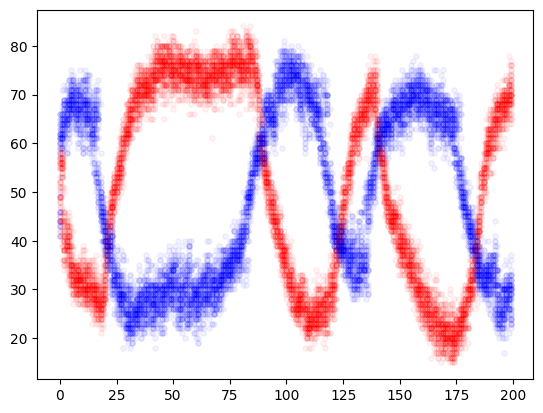

In [13]:
# Begin the evolution generations
for g in range(NGEN):
    #print("-- Generation %i --" % g)

    #We do the usual things with each population - create the offspring, mutate and calculate fitness
    #We could also add a crossover step here, as crossover happens with a population.
    # ----- HOSTS --------
    offspringHost = toolbox.select(popHost, len(popHost))
    offspringHost = list(map(toolbox.clone, offspringHost))

    for mutant in offspringHost:
        toolbox.mutateHost(mutant)

    fitnessesHost = map(toolbox.evaluateHost, offspringHost)
    for ind, fit in zip(offspringHost, fitnessesHost):
        ind.fitness.values = fit

    # ----- PARASITES --------
    offspringParasite = toolbox.select(popParasite, len(popParasite))
    offspringParasite = list(map(toolbox.clone, offspringParasite))

    for mutant in offspringParasite:
        toolbox.mutateParasite(mutant)

    fitnessesParasite = map(toolbox.evaluateParasite, offspringParasite)
    for ind, fit in zip(offspringParasite, fitnessesParasite):
        ind.fitness.values = fit

    #-- Reproduce both hosts and parasites --
    popHost[:] = offspringHost
    popParasite[:] = offspringParasite

    # Gather all the fitnesses in one list and print the stats
    fitsHost = [ind.fitness.values[0] for ind in popHost]
    fitsParasite = [ind.fitness.values[0] for ind in popParasite]
    #print ("Host: " + str(np.mean(fitsHost)) )
    #print ("Parasite: " + str(np.mean(fitsParasite)) )

    # Instead of loop make this a vector
    #for index in range(POPSIZE):
    gen = [g] * POPSIZE
    host = [sum(x) for x in popHost]
    parasite = [sum(x) for x in popParasite]
    plt.scatter( gen, host, color='red', s=15, alpha=0.05)
    plt.scatter( gen, parasite, color='blue', s=15, alpha=0.05)
    display.display(plt.gcf())
    display.clear_output(wait=True)


print("-- End of coevolution --")